In [1]:
try:
  %tensorflow_version 2.x
except Exception:
  pass

import tensorflow as tf
print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.20.0


In [2]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [3]:
#  abaixando o arquivo spam.csv
!wget https://lazyprogrammer.me/course_files/spam.csv

--2026-08-13 23:45:22--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3036::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  --.-KB/s    in 0.03s   

2026-08-13 23:45:41 (15.0 MB/s) - ‘spam.csv’ saved [503663/503663]



In [4]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1') # faz a leitura do csv, utiliza o encondigo para evitar erros

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1) # exclui as tres colunas desnecessárias

In [7]:
df.head() # mostra o inicio

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.columns = ['labels', 'data'] # defini duas colunas

In [9]:
df.head() # para vizualizar o inicio dnv

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Cria novas labels binarias
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1}) #Na nova coluna os labels ham teram o valor 0 e os labels spam terá 1
Y = df['b_labels'].values # pega os valores da coluna

In [11]:
df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size=0.33) # separa os dados em treino e teste

In [12]:
# Converte setencias em sequencias
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

In [13]:
word2idx = tokenizer.word_index # Pega o índice das palavras
V = len(word2idx) # Conta quantas palavras existem
print('Found %s unique tokens.' % V)

Found 7186 unique tokens.


In [15]:
data_train = pad_sequences(sequences_train) # Preenchendo as sequências
print('Shape of data train tensor: ', data_train.shape)

T = data_train.shape[1] # Pega o tamanho da sequência

Shape of data train tensor:  (3733, 189)


In [16]:
data_test = pad_sequences(sequences_test, maxlen=T) # Fazendo o mesmo com os dados de teste
print('Shape of data test tensor: ', data_test.shape)

Shape of data test tensor:  (1839, 189)


In [17]:
D = 20 # Tamanho do vetor de representação

i = Input(shape=(T,)) # Define a entrada da rede
x = Embedding(V + 1, D)(i) # Camada Embedding
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x) # cria o modelo

In [18]:
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

print('Training model...')
r = model.fit(
  data_train,
  Ytrain,
  epochs=10,
  validation_data=(data_test, Ytest)
)

Training model...
Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8837 - loss: 0.3392 - val_accuracy: 0.9538 - val_loss: 0.1447
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9770 - loss: 0.0761 - val_accuracy: 0.9810 - val_loss: 0.0585
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9912 - loss: 0.0230 - val_accuracy: 0.9869 - val_loss: 0.0546
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9979 - loss: 0.0096 - val_accuracy: 0.9875 - val_loss: 0.0514
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 0.9869 - val_loss: 0.0631
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9875 - val_loss: 0.0670
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9875 - val_loss: 0.0728
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9995 - loss:

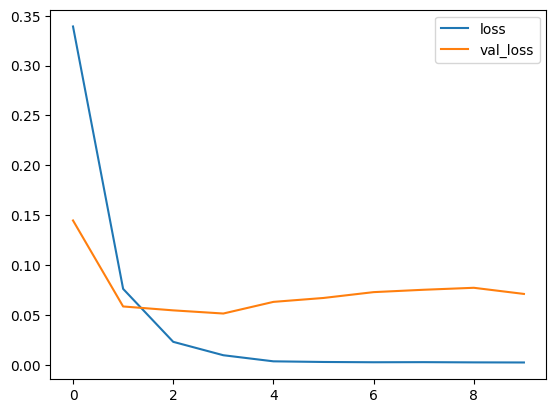

In [19]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

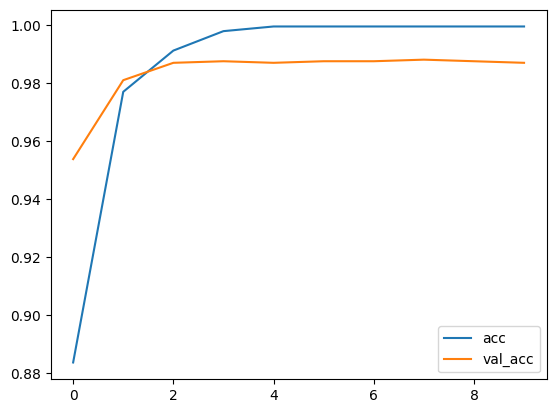

In [20]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()